***INTRODUCTION :***
In this project, we use two object detection models: YOLOv8n and SSDlite320 with MobileNetV3. Both models learn to locate digits in images and identify them by drawing bounding boxes and assigning labels from 0 to 9. We chose these models because they are lightweight and require fewer computing resources than larger detectors, making them suitable for our Google Colab project. We use the full_numbers version of the SVHN dataset, which provides images with digit labels and bounding boxes. Both models start with pretrained weights and are trained on the same 3,500 images. We then evaluate them on the same test set to compare their detection performance and training time.


In [16]:
# In this project, we train two object detection models to locate and recognize
# digits in images of street numbers. We use the "full_numbers" version of SVHN
# because it provides bounding boxes and labels for each annotated digit.
# In contrast, "cropped_digits" only provides the class of the central digit,
# making it suitable for classification rather than object detection.

!pip install numpy


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After installation, you can then import and use the library in subsequent cells:


In [18]:
import numpy as np


%pip -q install "ultralytics>=8.3,<9" "datasets>=3,<5" "torchmetrics>=1.6,<2" faster-coco-eval pillow pyyaml


## Connect Google Drive

To access files stored in your Google Drive, you can mount it to your Colab environment. This will prompt you to authorize Google Colab to access your Drive.


In [19]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This code imports the required libraries, connects Google Drive, checks GPU availability, sets the training parameters, and creates folders for the dataset and results.


In [20]:
from pathlib import Path
import json, time, gc, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm
import torch
import yaml
from google.colab import drive

# Connecter Google Drive.
drive.mount('/content/drive')

# Vérifier que le GPU est activé.
assert torch.cuda.is_available(), 'Active un GPU avant de continuer.'
print('GPU :', torch.cuda.get_device_name(0))

# Réglages de l'entraînement.
SEED = 42
EPOCHS = 10
BATCH = 16
IMAGE_SIZE = 320
DEVICE = torch.device('cuda')

torch.manual_seed(SEED)

# Dossier des images pour cette nouvelle expérience.
ROOT = Path('/content/svhn_3500')

# Dossier des résultats dans Google Drive.
SAVE = Path('/content/drive/MyDrive/Projet_SVHN/experience_3500')

# Créer les dossiers s'ils n'existent pas encore.
ROOT.mkdir(parents=True, exist_ok=True)
SAVE.mkdir(parents=True, exist_ok=True)

print('Les dossiers sont prêts.')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU : Tesla T4
Les dossiers sont prêts.


This code copies the dataset files from Google Drive to Colab, loads them, checks that they match the full_numbers format, and displays a sample image with its annotations


Training images: 33402
Test images: 13068
Annotations: {'bbox': [[38, 1, 21, 40], [57, 3, 16, 40]], 'label': [4, 6]}


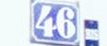

In [21]:
from datasets import load_dataset

# Locate the dataset folder in Google Drive.
folder = Path('/content/drive/MyDrive/SVHN_brut')
data_files = {}

# Copy the training and test files to Colab.
for split in ['train', 'test']:
    filename = f'{split}-00000-of-00001.parquet'
    source = folder / filename

    assert source.exists(), f'File not found: {source}'

    destination = Path('/content') / filename
    shutil.copy2(source, destination)
    data_files[split] = str(destination)

# Load the dataset.
dataset = load_dataset('parquet', data_files=data_files)

# Check the expected sizes and detection annotations.
assert len(dataset['train']) == 33402, 'Check that you downloaded full_numbers.'
assert len(dataset['test']) == 13068
assert 'digits' in dataset['train'].column_names

print('Training images:', len(dataset['train']))
print('Test images:', len(dataset['test']))

# Display a sample image and its annotations.
example = dataset['train'][0]
print('Annotations:', example['digits'])
display(example['image'])


Check the annotations on a few images
The green boxes should surround the digits matching their labels. These are the dataset’s ground-truth annotations, not model predictions. If the boxes or labels are incorrect, stop before training.


In [ ]:
indices = np.random.default_rng(SEED).permutation(33402)
train_ids = sorted(indices[:3500].tolist())
val_ids = sorted(indices[3500:].tolist())
test_ids = list(range(13068))

assert len(train_ids) == 3500
assert len(val_ids) == 29902
assert set(train_ids).isdisjoint(val_ids)

(SAVE / 'selection.json').write_text(json.dumps({
    'seed': SEED, 'train': train_ids, 'val': val_ids, 'test': test_ids
}))
print('Train :', len(train_ids), '| Validation :', len(val_ids), '| Test :', len(test_ids))

def prepare_images(source, indices, split):
    image_folder = ROOT / 'images' / split
    label_folder = ROOT / 'labels' / split

    image_folder.mkdir(parents=True, exist_ok=True)
    label_folder.mkdir(parents=True, exist_ok=True)

    records = []

    for index in tqdm(indices, desc=f'Preparing {split}'):
        example = source[index]
        image = example['image'].convert('RGB')
        image_width, image_height = image.size

        boxes = []
        labels = []
        yolo_annotations = []

        for box, label in zip(
            example['digits']['bbox'],
            example['digits']['label']
        ):
            x, y, width, height = map(float, box)
            label = int(label)
            assert 0 <= label <= 9

            # Keep the bounding box inside the image.
            x1 = min(max(x, 0), image_width)
            y1 = min(max(y, 0), image_height)
            x2 = min(max(x + width, 0), image_width)
            y2 = min(max(y + height, 0), image_height)

            if x2 <= x1 or y2 <= y1:
                continue

            # Coordinates used by SSD and the display function.
            boxes.append([x1, y1, x2, y2])
            labels.append(label)

            # Normalized coordinates used by YOLO.
            center_x = (x1 + x2) / (2 * image_width)
            center_y = (y1 + y2) / (2 * image_height)
            box_width = (x2 - x1) / image_width
            box_height = (y2 - y1) / image_height

            yolo_annotations.append(
                f'{label} {center_x:.8f} {center_y:.8f} '
                f'{box_width:.8f} {box_height:.8f}'
            )

        filename = f'{index:06d}'
        image_path = image_folder / f'{filename}.png'
        image.save(image_path)

        label_path = label_folder / f'{filename}.txt'
        label_path.write_text('\n'.join(yolo_annotations))

        records.append({
            'image': image_path.relative_to(ROOT).as_posix(),
            'boxes': boxes,
            'labels': labels
        })

    return records


# Prepare the three image sets.
train_records = prepare_images(dataset['train'], train_ids, 'train')
val_records = prepare_images(dataset['train'], val_ids, 'val')
test_records = prepare_images(dataset['test'], test_ids, 'test')

# Create the configuration file needed by YOLO.
config = {
    'path': str(ROOT),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {i: str(i) for i in range(10)}
}

YAML_PATH = ROOT / 'svhn.yaml'
YAML_PATH.write_text(yaml.safe_dump(config, sort_keys=False))

print('Train:', len(train_records))
print('Validation:', len(val_records))
print('Test:', len(test_records))


Train : 3500 | Validation : 29902 | Test : 13068


Preparing train:   0%|          | 0/3500 [00:00<?, ?it/s]

Preparing val:   0%|          | 0/29902 [00:00<?, ?it/s]

This code displays six training images with their ground-truth bounding boxes and digit labels to check the annotations before training.


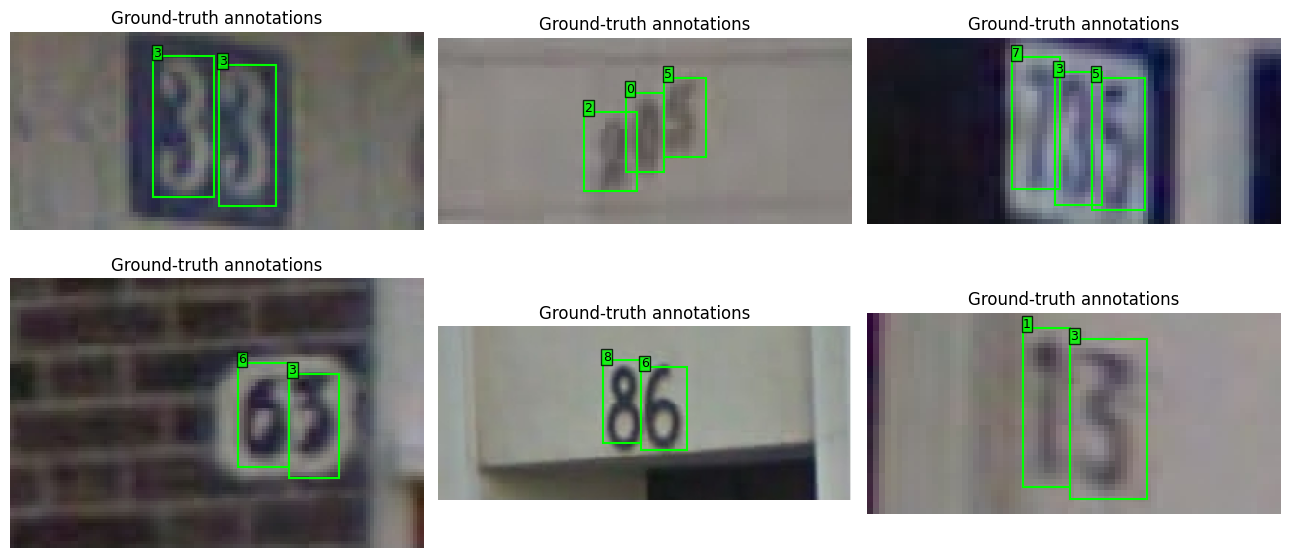

In [8]:
def show_boxes(ax, image, boxes, labels, scores=None, title=''):
    ax.imshow(image)

    for i, (box, label) in enumerate(zip(boxes, labels)):
        x1, y1, x2, y2 = map(float, box)

        # Draw a green bounding box.
        ax.add_patch(patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=1.5,
            edgecolor='lime',
            facecolor='none'
        ))

        # Display the digit label and an optional confidence score.
        text = str(int(label))

        if scores is not None:
            text += f' ({float(scores[i]):.2f})'

        ax.text(
            x1, y1, text,
            color='black',
            fontsize=9,
            bbox={'facecolor': 'lime', 'alpha': 0.8, 'pad': 1}
        )

    ax.set_title(title)
    ax.axis('off')


# Display the first six training images with their annotations.
fig, axes = plt.subplots(2, 3, figsize=(13, 6))

for ax, record in zip(axes.flat, train_records[:6]):
    with Image.open(ROOT / record['image']) as source:
        image = source.convert('RGB')

    show_boxes(
        ax,
        image,
        record['boxes'],
        record['labels'],
        title='Ground-truth annotations'
    )

plt.tight_layout()
plt.savefig(SAVE / 'annotations_exemples.png', dpi=160)
plt.show()



***First Model to Train: YOLOv8n***
The model is pretrained on COCO and then fine-tuned to detect the ten digit classes. Data augmentation is disabled for this initial experiment, including flips that could change the appearance of digits. The validation set is used to select the best checkpoint, saved as best.pt. The test set is not used during training.
If this experiment already exists, change the SAVE folder to start a new one. If training has already completed, skip this cell.
We use YOLOv8n because it can find digits in an image and identify them at the same time. For each detected digit, it draws a bounding box and predicts a label from 0 to 9. The letter “n” means “nano”, which is the smallest version of YOLOv8. It needs fewer computing resources than the larger versions, making it a practical choice for our Google Colab project.
The code first loads a pretrained model. This means the model has already learned useful visual features from another dataset called COCO, but it still needs training to recognize the digits in SVHN.
Next, we train it on 3,500 images for 10 epochs. An epoch is one complete pass through the training images. During training, the model compares its predictions with the correct digit labels and bounding boxes, then adjusts its parameters to reduce its mistakes.
The code also uses a separate validation set to check the model’s progress and save the best version as best.pt. Finally, it records the time taken and frees GPU memory for the second model. The test images are kept for the final evaluation.


In [9]:
from ultralytics import YOLO

# Prevent overwriting an existing experiment.
assert not (SAVE / 'yolo').exists(), (
    'This experiment already exists. Change SAVE to start a new one.'
)

# Load the pretrained YOLOv8 nano model.
yolo = YOLO('yolov8n.pt')

# Check that the model uses exactly 3,500 training images.
def check_train_size(trainer):
    assert len(trainer.train_loader.dataset) == 3500, (
        'The training dataset must contain exactly 3,500 images.'
    )

yolo.add_callback('on_train_start', check_train_size)

# Start the timer.
start = time.perf_counter()

# Train the model.
yolo.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    imgsz=320,
    batch=BATCH,
    device=0,
    workers=2,
    seed=SEED,
    project=str(SAVE),
    name='yolo',
    patience=EPOCHS + 1,
    cache=False,

    # Disable data augmentation.
    fliplr=0,
    flipud=0,
    mosaic=0,
    mixup=0,
    copy_paste=0,
    degrees=0,
    translate=0,
    scale=0,
    shear=0,
    perspective=0,
    hsv_h=0,
    hsv_s=0,
    hsv_v=0
)

# Save the elapsed time, including validation and checkpoint saving.
minutes = (time.perf_counter() - start) / 60
(SAVE / 'yolo_minutes.txt').write_text(str(minutes))

print(f'Training completed in {minutes:.1f} minutes.')
print('Best model saved to:', SAVE / 'yolo/weights/best.pt')

# Release GPU memory before training SSDlite.
del yolo
gc.collect()
torch.cuda.empty_cache()


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/svhn_3500/svhn.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0, flipud=0, format=torchscript, fraction=1.0, freeze=N

***Prepare SSDlite :***
The class below loads the same images as YOLO. SSD reserves class 0 for the background, so we add 1 to the digit labels during training and subtract 1 from the predicted labels afterward. It therefore uses 11 internal classes: the background and the ten digits.
***Second Model SSDLite320 with MobileNetV3: ***
We use SSDlite320 with MobileNetV3 as our second object detection model. Like YOLOv8n, it finds digits in an image, draws a bounding box around each one, and predicts a label from 0 to 9. SSDlite is a lightweight version of SSD, designed to use fewer computing resources. MobileNetV3 is the part of the model that learns to recognize visual features, such as shapes and edges, while 320 refers to the 320 × 320 image size used by the model. We chose it because it is a relatively small detector and gives us a different method to compare with YOLOv8n. It also starts with pretrained weights, which we adapt to the digits in SVHN. We train both models on the same 3,500 images and evaluate them on the same test set to compare how well they find the digits and how long their training takes.


In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms.functional import to_tensor


class SVHNDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]

        # Load the image and convert pixels to values between 0 and 1.
        with Image.open(ROOT / record['image']) as source:
            image = to_tensor(source.convert('RGB'))

        # SSD reserves label 0 for the background.
        target = {
            'boxes': torch.tensor(
                record['boxes'],
                dtype=torch.float32
            ).reshape(-1, 4),

            'labels': torch.tensor(
                record['labels'],
                dtype=torch.int64
            ) + 1
        }

        return image, target


# Group images and annotations into batches.
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


# Training data: shuffle the images at each epoch.
train_loader = DataLoader(
    SVHNDataset(train_records),
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn,
    drop_last=False
)

# Validation data: keep the original order.
val_loader = DataLoader(
    SVHNDataset(val_records),
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

# Check the number of training images.
assert len(train_loader.dataset) == 3500

print('Training images:', len(train_loader.dataset))
print('Validation images:', len(val_loader.dataset))


Training images: 3500
Validation images: 29902


SSD is also pretrained on COCO. We replace only its classification head so it can recognize our digits. This setup requires more code than YOLO because Torchvision does not provide the same one-line training command.


In [11]:
from functools import partial
from torch import nn
from torchvision.models.detection import (
    ssdlite320_mobilenet_v3_large,
    SSDLite320_MobileNet_V3_Large_Weights
)
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead


def build_ssd():
    # Load the model pretrained on COCO.
    model = ssdlite320_mobilenet_v3_large(
        weights=SSDLite320_MobileNet_V3_Large_Weights.DEFAULT,
        trainable_backbone_layers=6,
        score_thresh=0.001,
        nms_thresh=0.5,
        detections_per_img=20
    )

    # Find the feature dimensions without training the model.
    model.eval()

    with torch.no_grad():
        features = model.backbone(torch.zeros(1, 3, 320, 320))

    channels = [
        feature.shape[1]
        for feature in features.values()
    ]

    anchors = model.anchor_generator.num_anchors_per_location()

    # Replace the classification head:
    # 10 digits + 1 background class = 11 classes.
    model.head.classification_head = SSDLiteClassificationHead(
        channels,
        anchors,
        11,
        partial(nn.BatchNorm2d, eps=0.001, momentum=0.03)
    )

    return model


# Move the model to the GPU.
ssd = build_ssd().to(DEVICE)

print('SSDlite is ready for digits from 0 to 9.')


Downloading: "https://download.pytorch.org/models/ssdlite320_mobilenet_v3_large_coco-a79551df.pth" to /root/.cache/torch/hub/checkpoints/ssdlite320_mobilenet_v3_large_coco-a79551df.pth


100%|██████████| 13.4M/13.4M [00:00<00:00, 60.8MB/s]


SSDlite is ready for digits from 0 to 9.


To compare our two models, we use mean Average Precision (mAP), which measures how well they identify the digits and place bounding boxes around them. A higher score means better detection performance. mAP50 uses an overlap threshold of 50% between a predicted box and the correct box, while mAP50-95 averages the results across overlap thresholds from 50% to 95%, making it stricter. These scores do not represent the percentage of images where every digit is correctly detected. For a fair final comparison, we evaluate both models on the same test images using the same metric calculation and detection settings: a minimum confidence score of 0.001, an NMS threshold of 0.5 to reduce duplicate detections, and a maximum of 20 predictions per image.


In [12]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision


# Create the metric used to evaluate detections.
def new_metric():
    return MeanAveragePrecision(
        box_format='xyxy',
        iou_type='bbox',
        max_detection_thresholds=[1, 10, 20],
        backend='faster_coco_eval'
    )


# Evaluate without calculating gradients or updating the model.
@torch.inference_mode()
def evaluate_ssd(model, loader):
    model.eval()
    metric = new_metric()

    for images, targets in tqdm(
        loader,
        desc='Evaluating SSD',
        leave=False
    ):
        outputs = model([image.to(DEVICE) for image in images])

        predictions = []
        truths = []

        for output, target in zip(outputs, targets):
            # Convert SSD labels back to digits from 0 to 9.
            predictions.append({
                'boxes': output['boxes'].cpu(),
                'scores': output['scores'].cpu(),
                'labels': output['labels'].cpu() - 1
            })

            truths.append({
                'boxes': target['boxes'].cpu(),
                'labels': target['labels'].cpu() - 1
            })

        metric.update(predictions, truths)

    # Calculate scores over the entire dataset passed to the function.
    result = metric.compute()

    scores = {
        'map': float(result['map']),
        'map_50': float(result['map_50'])
    }

    metric.reset()
    return scores


In this step, we train SSDlite on our 3,500 training images for 10 epochs. For each batch of images, the model predicts the digits and their bounding boxes, compares them with the correct annotations, and adjusts its parameters to reduce its errors. After each epoch, we evaluate it on the 29,902 validation images and save the best model in Google Drive. The test images are not used during training. In this simplified code, running the training cell again starts a new training process from the pretrained COCO weights rather than continuing from where it stopped.
After training both models, we evaluate them on the 13,068 images from the official test set, which were not used during training or validation. For each model, we load the version that achieved the best validation score. We then compare their detection scores and training times. Both models use an input size of 320 × 320 pixels, but their image preprocessing and optimization methods differ, so the results compare their complete setups rather than just their architectures. The recorded training times include validation and model saving. We use the test results only for the final comparison, not to adjust the models afterward.


In [14]:
from torch.utils.data import DataLoader

# Process 8 images at a time.
BATCH = 8

# Prepare the training batches.
train_loader = DataLoader(
    SVHNDataset(train_records),
    batch_size=BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    collate_fn=collate_fn,
    drop_last=False
)

# Prepare the validation batches.
val_loader = DataLoader(
    SVHNDataset(val_records),
    batch_size=BATCH,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=collate_fn
)

# Check the number of images.
assert len(train_loader.dataset) == 3500
assert len(val_loader.dataset) == 29902

print("Training images:", len(train_loader.dataset))
print("Validation images:", len(val_loader.dataset))
print("Images per batch:", BATCH)
print("Ready to train SSDlite.")

Training images: 3500
Validation images: 29902
Images per batch: 8
Ready to train SSDlite.


Comparing the two algorithmq


In [15]:
test_loader = DataLoader(
    SVHNDataset(test_records), batch_size=BATCH, shuffle=False,
    num_workers=2, pin_memory=True, collate_fn=collate_fn
)

ssd.load_state_dict(torch.load(SAVE / 'ssd_best.pth', map_location=DEVICE, weights_only=True))
torch.cuda.synchronize()
start = time.perf_counter()
ssd_scores = evaluate_ssd(ssd, test_loader)
torch.cuda.synchronize()
ssd_test_seconds = time.perf_counter() - start
ssd.cpu()
torch.cuda.empty_cache()

best_yolo = YOLO(str(SAVE / 'yolo/weights/best.pt'))
metric = new_metric()
start = time.perf_counter()

for offset in tqdm(range(0, len(test_records), BATCH), desc='Test YOLO'):
    records = test_records[offset:offset + BATCH]
    paths = [str(ROOT / record['image']) for record in records]
    outputs = best_yolo.predict(
        source=paths, imgsz=IMAGE_SIZE, device=0,
        conf=0.001, iou=0.5, max_det=20,
        rect=False, half=False, verbose=False
    )
    predictions, truths = [], []
    for output, record in zip(outputs, records):
        predictions.append({
            'boxes': output.boxes.xyxy.cpu(),
            'scores': output.boxes.conf.cpu(),
            'labels': output.boxes.cls.to(torch.int64).cpu()
        })
        truths.append({
            'boxes': torch.tensor(record['boxes'], dtype=torch.float32).reshape(-1, 4),
            'labels': torch.tensor(record['labels'], dtype=torch.int64)
        })
    metric.update(predictions, truths)

yolo_result = metric.compute()
yolo_scores = {'map': float(yolo_result['map']), 'map_50': float(yolo_result['map_50'])}
metric.reset()
torch.cuda.synchronize()
yolo_test_seconds = time.perf_counter() - start


comparison = pd.DataFrame([
    {'Modèle': 'YOLOv8n', 'mAP50 (%)': 100 * yolo_scores['map_50'],
     'mAP50-95 (%)': 100 * yolo_scores['map'],
     'Entraînement avec validation (min)': float((SAVE / 'yolo_minutes.txt').read_text())},
    {'Modèle': 'SSDlite MobileNetV3', 'mAP50 (%)': 100 * ssd_scores['map_50'],
     'mAP50-95 (%)': 100 * ssd_scores['map'],
     'Entraînement avec validation (min)': float((SAVE / 'ssd_minutes.txt').read_text())}
])
comparison.to_csv(SAVE / 'comparaison_test.csv', index=False)
display(comparison.round(2))



FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Projet_SVHN/experience_3500/ssd_best.pth'

See detections and results


In [ ]:
ssd.to(DEVICE).eval()
sample_records = test_records[:4]
fig, axes = plt.subplots(len(sample_records), 3, figsize=(14, 10))

for row, record in enumerate(sample_records):
    with Image.open(ROOT / record['image']) as source:
        image = source.convert('RGB')
    show_boxes(axes[row, 0], image, record['boxes'], record['labels'], title='Vérité terrain')

    pred_yolo = best_yolo.predict(
        image, imgsz=IMAGE_SIZE, conf=0.25, iou=0.5,
        max_det=20, rect=False, device=0, verbose=False
    )[0]
    show_boxes(axes[row, 1], image, pred_yolo.boxes.xyxy.cpu().numpy(),
               pred_yolo.boxes.cls.cpu().numpy(), pred_yolo.boxes.conf.cpu().numpy(), 'YOLOv8n')

    with torch.inference_mode():
        pred_ssd = ssd([to_tensor(image).to(DEVICE)])[0]
    keep = pred_ssd['scores'] >= 0.25
    show_boxes(axes[row, 2], image, pred_ssd['boxes'][keep].cpu().numpy(),
               (pred_ssd['labels'][keep] - 1).cpu().numpy(),
               pred_ssd['scores'][keep].cpu().numpy(), 'SSDlite')

plt.tight_layout()
plt.savefig(SAVE / 'comparaison_visuelle.png', dpi=160)
plt.show()
